# BloodMNIST – Klasyfikacja obrazów krwi
## Sieci fully-connected i konwolucyjna

Maciej Gilecki 173142

**Zbiór danych:** BloodMNIST (MedMNIST v2, rozdzielczość 28×28)  
**Klasy:** 8 typów komórek krwi (neutrofil, eozynofil, bazofil, limfocyt, monocyt, IG, płytki, erytrocyty)  
**Framework:** Keras / TensorFlow



**Lab 3**

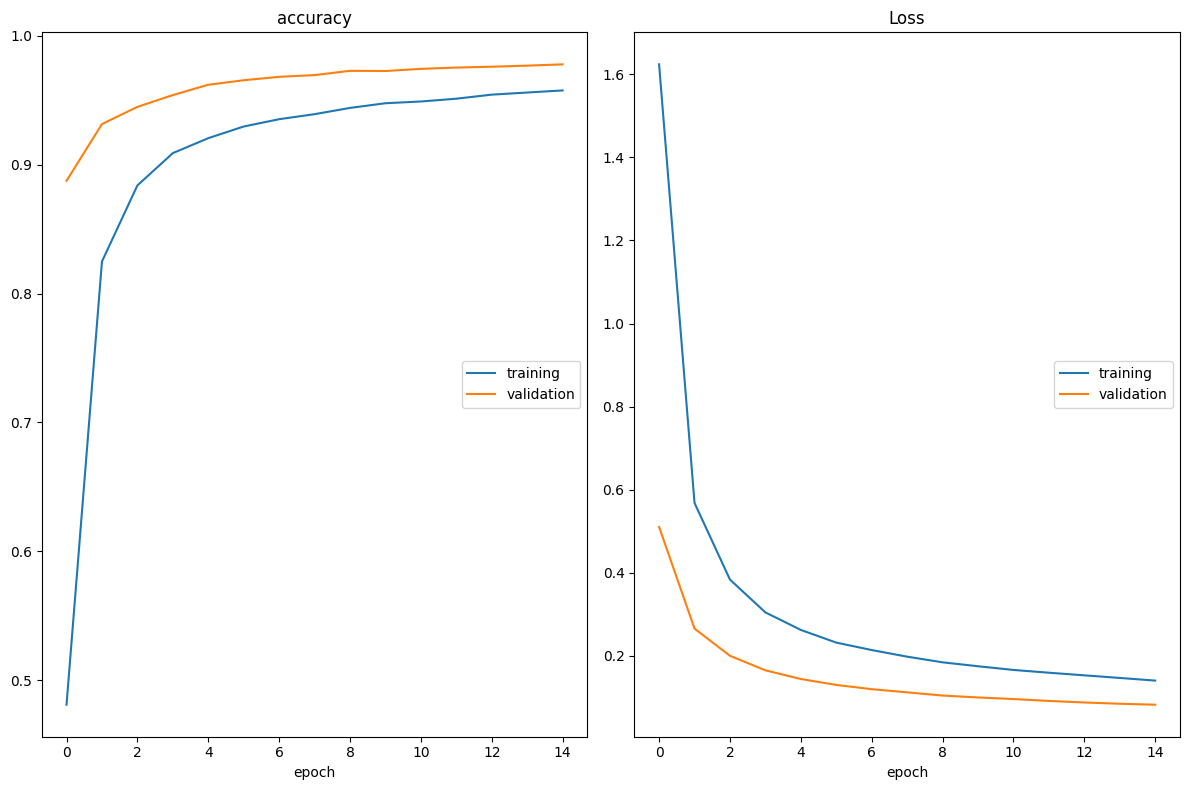

accuracy
	training         	 (min:    0.481, max:    0.958, cur:    0.958)
	validation       	 (min:    0.887, max:    0.978, cur:    0.978)
Loss
	training         	 (min:    0.140, max:    1.624, cur:    0.140)
	validation       	 (min:    0.082, max:    0.510, cur:    0.082)
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9576 - loss: 0.1405 - val_accuracy: 0.9778 - val_loss: 0.0824
Test loss: 0.08817298710346222
Test accuracy: 0.9733999967575073


In [68]:
#https://keras.io/examples/vision/mnist_convnet/

import numpy as np
import keras
from keras import layers

#dodatkowe pakiety
!pip install livelossplot
from livelossplot import PlotLossesKeras

# callbacks = [PlotLosseesKeras()]
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks = [PlotLossesKeras()])

score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

In [69]:
predict = model.predict(x_test)
classes_predicted = np.argmax(predict, axis = 1)
classes = np.argmax(y_test, axis = 1)
confusion_matrix(classes, classes_predicted)
#confusion_matrix(classes, classes_predicted, labels = range(0, 10))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


array([[ 973,    0,    1,    0,    0,    1,    1,    1,    3,    0],
       [   0, 1126,    4,    1,    0,    0,    2,    0,    2,    0],
       [   4,    0, 1005,    1,    3,    1,    0,   11,    7,    0],
       [   0,    0,    5,  981,    0,    9,    0,    8,    6,    1],
       [   1,    2,    3,    0,  953,    0,    6,    3,    2,   12],
       [   2,    0,    1,   10,    1,  872,    2,    1,    3,    0],
       [   9,    3,    0,    0,    3,    5,  936,    0,    2,    0],
       [   1,    5,   21,    3,    0,    1,    0,  983,    4,   10],
       [   7,    0,    3,    5,    3,    2,    2,    7,  934,   11],
       [   5,    7,    1,    8,    2,    6,    1,    5,    3,  971]])

1901 3869


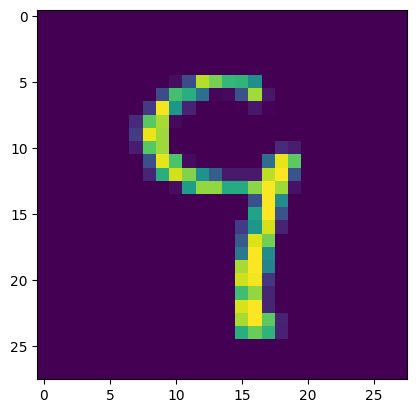

In [70]:
etykiety = []
for idx in range(0, len(classes)):
  if (classes[idx] == 9) and (classes_predicted[idx] == 4):
    etykiety.append(idx)

print(*etykiety)
plt.imshow(x_test[1192, :, :])

Konwolucyjna sieć

In [71]:
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model_no_max_pool = keras.Model(inputs=inputs, outputs=outputs)
model_no_max_pool.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

**Lab 3**

In [72]:
!pip install medmnist livelossplot --quiet

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from medmnist import BloodMNIST, INFO
from livelossplot import PlotLossesKeras

print("Kares: ", keras.__version__)

Kares:  3.13.2


### Zbiór danych

**BloodMNIST** jest częścią kolekcji **MedMNIST v2** — zestawu 18 medycznych zbiorów obrazów standaryzowanych do rozdzielczości 28×28 px, zaprojektowanego jako benchmark dla algorytmów uczenia maszynowego w medycynie.

Zdjęcia pochodzą z mikroskopii optycznej obwodowej krwi i przedstawiają 8 morfologicznych klas leukocytów oraz erytrocytów:

| Indeks | Klasa | Opis |
|--------|-------|------|
| 0 | basophil | bazofil |
| 1 | eosinophil | eozynofil |
| 2 | erythroblast | erytroblast |
| 3 | ig | niedojrzałe granulocyty |
| 4 | lymphocyte | limfocyt |
| 5 | monocyte | monocyt |
| 6 | neutrophil | neutrofil |
| 7 | platelet | płytka krwi |

### Podział danych

Zbiór jest wstępnie podzielony na **trzy rozłączne podzbiory**:
- **treningowy** (*train*) – służy do uczenia wag sieci,
- **walidacyjny** (*val*) – monitorowanie generalizacji w trakcie uczenia (early stopping, dobór hiperparametrów),
- **testowy** (*test*) – jednorazowa ocena końcowa modelu; **nie wolno** go używać podczas doboru architektury.

### Normalizacja

Piksele obrazów RGB przyjmują wartości całkowite z zakresu **[0, 255]**.  
Dzielimy je przez 255, uzyskując wartości zmiennoprzecinkowe **[0.0, 1.0]**.  
Normalizacja przyspiesza zbieżność gradientowego uczenia, bo zapobiega dominowaniu dużych wartości wejściowych.

Liczba klas: 8
Klasy: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Train: (11959, 28, 28, 3)
Val:   (1712, 28, 28, 3)
Test:  (3421, 28, 28, 3)


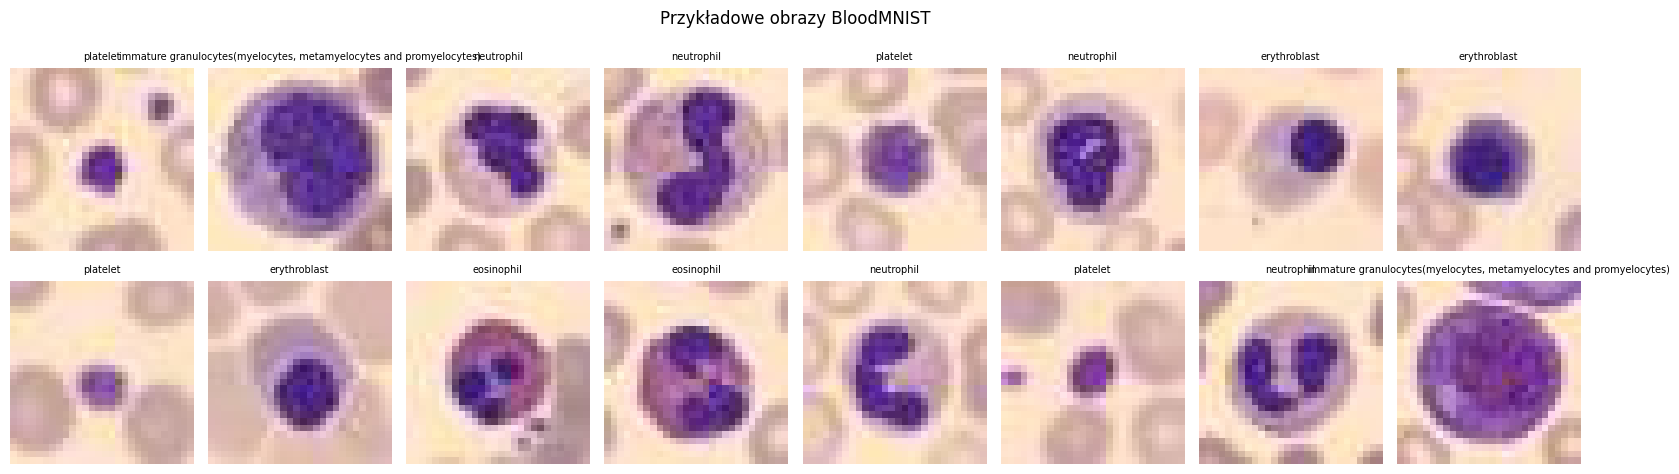

In [73]:
info = INFO['bloodmnist']
N_CLASSES = len(info['label'])
CLASS_NAMES = list(info['label'].values())
print('Liczba klas:', N_CLASSES)
print('Klasy:', CLASS_NAMES)

def load_split(split):
    ds = BloodMNIST(split=split, download=True, size=28)
    x = ds.imgs.astype('float32') / 255.0
    y = ds.labels.squeeze().astype('int32')
    return x, keras.utils.to_categorical(y, N_CLASSES)

x_train, y_train = load_split('train')
x_val,   y_val   = load_split('val')
x_test,  y_test  = load_split('test')

print(f'Train: {x_train.shape}')
print(f'Val:   {x_val.shape}')
print(f'Test:  {x_test.shape}')

# Podgląd przykładowych obrazów
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[np.argmax(y_train[i])], fontsize=7)
    ax.axis('off')
plt.suptitle('Przykładowe obrazy BloodMNIST', fontsize=12)
plt.tight_layout()
plt.show()

### Macierz pomyłek

**Macierz pomyłek** (ang. *confusion matrix*) to kwadratowa macierz **C** rozmiaru *K×K*, gdzie *K* to liczba klas.  
Element **C[i, j]** oznacza liczbę przykładów klasy *i*, które model sklasyfikował jako klasę *j*.

- **Przekątna główna** – poprawne klasyfikacje (TP dla każdej klasy).
- **Elementy poza przekątną** – pomyłki (FP / FN).

Z macierzy wyliczamy dla każdej klasy:

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}, \quad F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**F1-score** jest szczególnie ważny przy niezbalansowanych klasach — sam *accuracy* może być mylący.

In [74]:
def plot_confusion(model, x, y_cat, title='Macierz pomyłek'):
    y_true = np.argmax(y_cat, axis=1)
    y_pred = np.argmax(model.predict(x, verbose=0), axis=1)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_history(histories: dict, title='Krzywe uczenia'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in histories.items():
        axes[0].plot(hist.history['val_loss'],     label=name)
        axes[1].plot(hist.history['val_accuracy'], label=name)

    axes[0].set_title('Val Loss')
    axes[0].set_xlabel('Epoka')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_title('Val Accuracy')
    axes[1].set_xlabel('Epoka')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Perceptron wielowarstwowy (MLP)

**Sieć w pełni połączona** (ang. *fully-connected*, *dense*, MLP) składa się z warstw, w których każdy neuron jest połączony z każdym neuronem warstwy poprzedniej.

Pojedynczy neuron warstwy *l* oblicza:
$$z^{(l)} = W^{(l)} \cdot a^{(l-1)} + b^{(l)}, \quad a^{(l)} = f(z^{(l)})$$
gdzie $f$ to **funkcja aktywacji**.

### Funkcje aktywacji

| Funkcja | Wzór | Zastosowanie |
|---------|------|--------------|
| **ReLU** | $\max(0, x)$ | warstwy ukryte – szybka, brak problemu zanikającego gradientu |
| **Softmax** | $\frac{e^{x_i}}{\sum_j e^{x_j}}$ | warstwa wyjściowa klasyfikacji wieloklasowej |

### Funkcja straty

Dla klasyfikacji wieloklasowej stosujemy **categorical cross-entropy**:
$$L = -\sum_{k=1}^{K} y_k \log(\hat{y}_k)$$
gdzie $y_k$ to etykieta one-hot, a $\hat{y}_k$ – przewidywane prawdopodobieństwo.

### Optymalizator Adam

**Adam** (*Adaptive Moment Estimation*) łączy zalety algorytmów **RMSProp** i **Momentum**:
- utrzymuje adaptacyjny learning rate dla każdego parametru,
- estymuje pierwsze i drugie momenty gradientu,
- zazwyczaj zbiega szybciej niż klasyczne SGD.

### Regularyzacja

- **Dropout** – w każdym kroku treningu losowo *wyłącza* określony procent neuronów, zmuszając sieć do uczenia redundantnych reprezentacji → redukuje overfitting.
- **BatchNormalization** – normalizuje aktywacje wewnątrz batcha; stabilizuje i przyspiesza uczenie, działa jak lekki regularyzator.

### FC – Mała sieć (baseline)

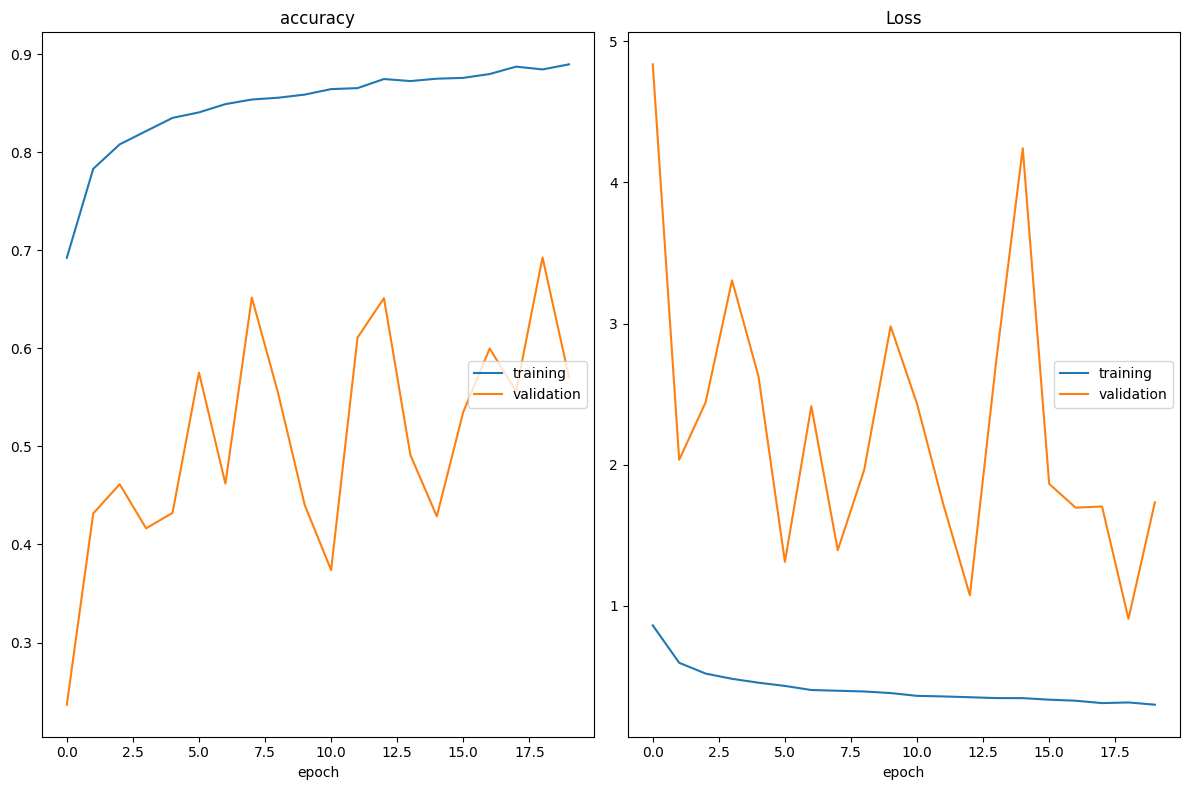

accuracy
	training         	 (min:    0.692, max:    0.890, cur:    0.890)
	validation       	 (min:    0.237, max:    0.693, cur:    0.571)
Loss
	training         	 (min:    0.298, max:    0.861, cur:    0.298)
	validation       	 (min:    0.907, max:    4.837, cur:    1.733)
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8897 - loss: 0.2983 - val_accuracy: 0.5707 - val_loss: 1.7328


In [75]:
model_fc1 = keras.Sequential([
    keras.Input(shape=(28, 28, 3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='FC_v1')

model_fc1.summary()

model_fc1.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

history_fc1 = model_fc1.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=[PlotLossesKeras()]
)

In [76]:
score_fc1 = model_fc1.evaluate(x_test, y_test, verbose=0)
print(f'FC v1 – Test loss: {score_fc1[0]:.4f} | Test accuracy: {score_fc1[1]:.4f}')

FC v1 – Test loss: 1.7106 | Test accuracy: 0.5756


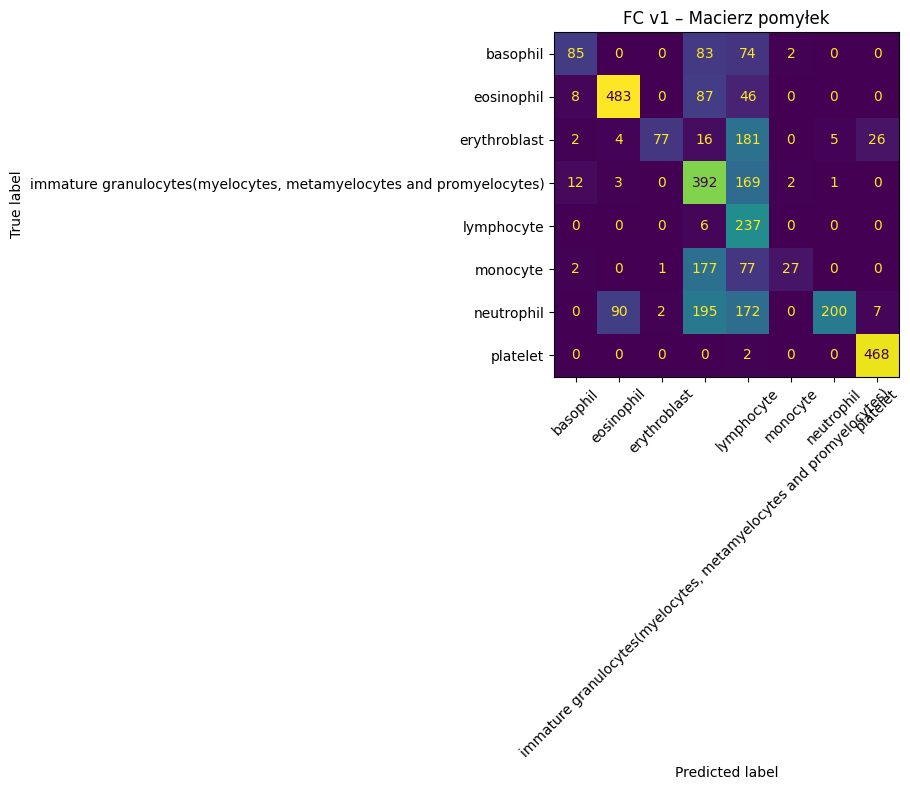

In [77]:
plot_confusion(model_fc1, x_test, y_test, 'FC v1 – Macierz pomyłek')

### FC – Głębsza sieć z BatchNorm i Dropout

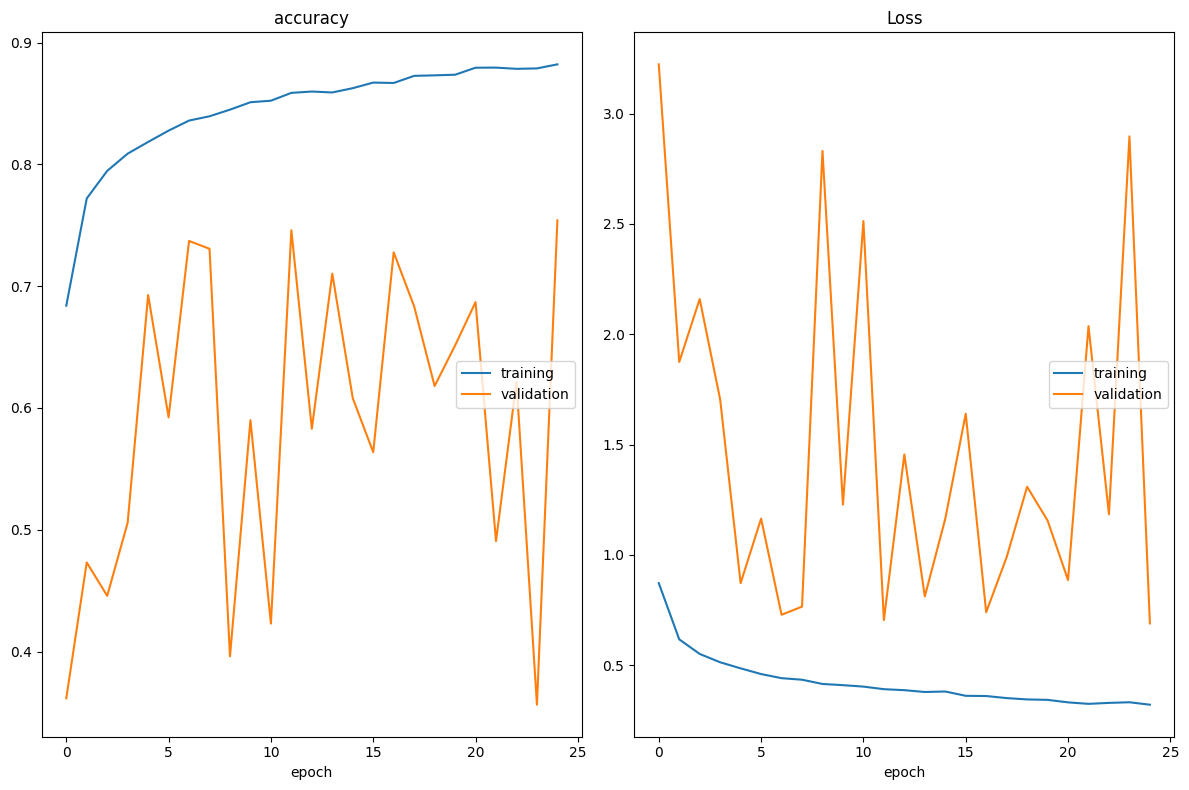

accuracy
	training         	 (min:    0.684, max:    0.882, cur:    0.882)
	validation       	 (min:    0.356, max:    0.754, cur:    0.754)
Loss
	training         	 (min:    0.322, max:    0.872, cur:    0.322)
	validation       	 (min:    0.690, max:    3.223, cur:    0.690)
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8822 - loss: 0.3215 - val_accuracy: 0.7541 - val_loss: 0.6898


In [78]:
model_fc2 = keras.Sequential([
    keras.Input(shape=(28, 28, 3)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='FC_v2')

model_fc2.summary()

model_fc2.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

history_fc2 = model_fc2.fit(
    x_train, y_train,
    batch_size=64,
    epochs=25,
    validation_data=(x_val, y_val),
    callbacks=[PlotLossesKeras()]
)

In [79]:
score_fc2 = model_fc2.evaluate(x_test, y_test, verbose=0)
print(f'FC v2 – Test loss: {score_fc2[0]:.4f} | Test accuracy: {score_fc2[1]:.4f}')

FC v2 – Test loss: 0.6893 | Test accuracy: 0.7545


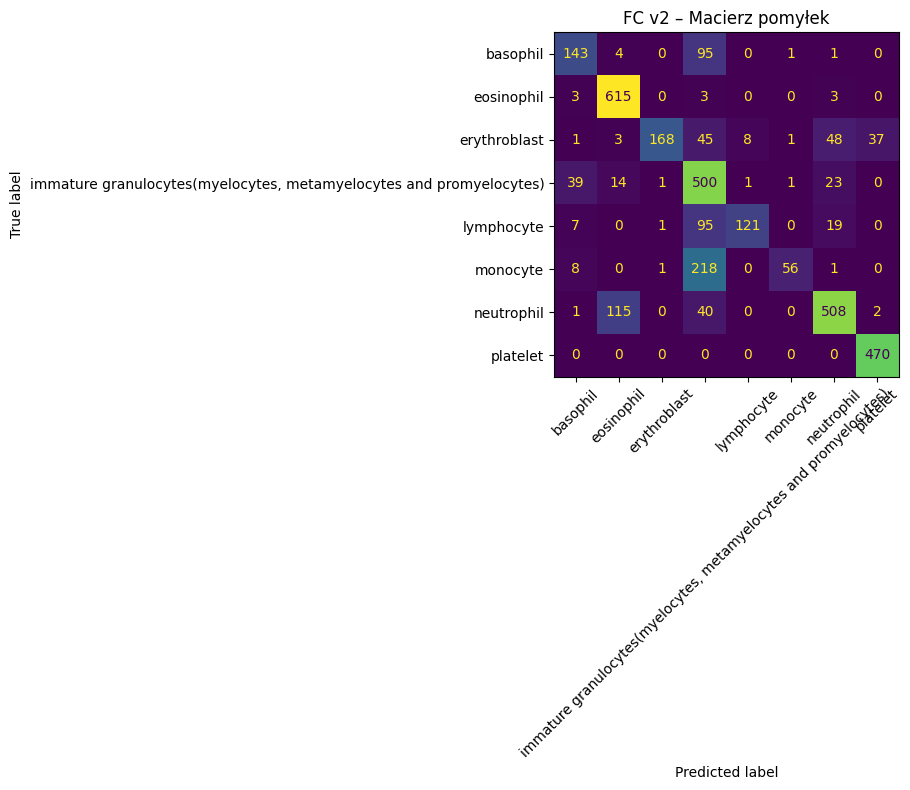

In [80]:
plot_confusion(model_fc2, x_test, y_test, 'FC v2 – Macierz pomyłek')

### Sieć Konwolucyjna (CNN)

**Konwolucja 2D** przesuwa uczony **filtr** (kernel) o rozmiarze *k×k* po obrazie wejściowym i oblicza iloczyn skalarny w każdym położeniu:

$$S(i,j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I(i+m,\, j+n) \cdot K(m,n)$$

Wynikiem jest **mapa cech** (*feature map*). Wiele filtrów = wiele map = warstwy głębokości (*channels*).

### Dlaczego CNN lepiej niż FC dla obrazów?

| Cecha | FC | CNN |
|-------|----|-----|
| Zachowanie informacji przestrzennej | ✗ (flatten) | ✓ |
| Współdzielenie wag | ✗ | ✓ (ten sam filtr po całym obrazie) |
| Liczba parametrów | bardzo duża | znacznie mniejsza |
| Niezmienniczość na przesunięcia | ✗ | ✓ (przez pooling) |

### Kluczowe operacje

- **padding='same'** – dopełnienie zerami, aby mapa cech miała taki sam rozmiar co wejście.
- **MaxPooling2D(2,2)** – redukuje rozmiar przestrzenny o czynnik 2, wybierając maksimum w oknie 2×2. Zapewnia lokalną niezmienniczość na przesunięcia.
- **GlobalAveragePooling2D** – zastępuje Flatten, obliczając średnią każdej mapy cech → redukuje liczbę parametrów i działa jak regularyzator.
- **BatchNormalization** po Conv2D – normalizuje aktywacje w obrębie batcha; pozwala na wyższe learning rate i przyspiesza zbieżność.
- **Dropout2d** – zeruje losowe kanały (całe mapy cech), bardziej odpowiedni dla CNN niż klasyczny Dropout.

### CNN – Prosta sieć (2 bloki)

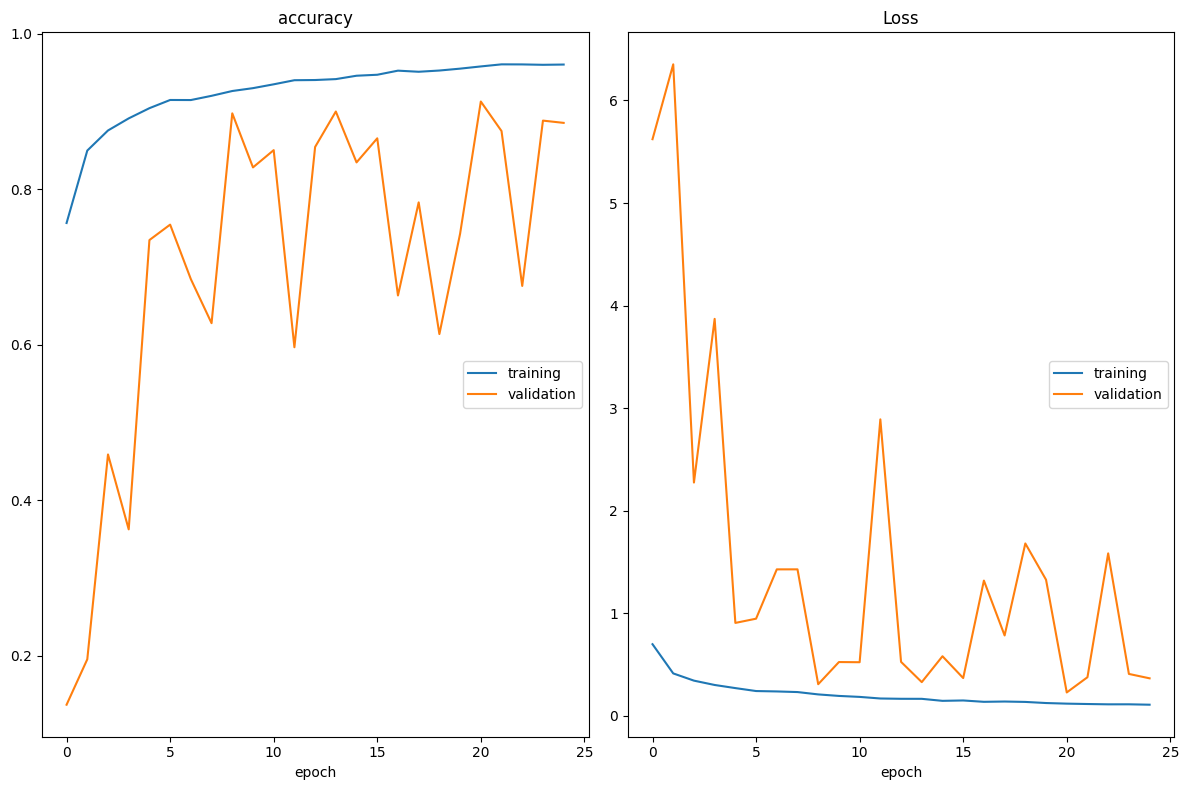

accuracy
	training         	 (min:    0.757, max:    0.961, cur:    0.961)
	validation       	 (min:    0.137, max:    0.913, cur:    0.886)
Loss
	training         	 (min:    0.108, max:    0.698, cur:    0.108)
	validation       	 (min:    0.227, max:    6.352, cur:    0.365)
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9605 - loss: 0.1079 - val_accuracy: 0.8855 - val_loss: 0.3651


In [81]:
model_cnn1 = keras.Sequential([
    keras.Input(shape=(28, 28, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='CNN_v1')

model_cnn1.summary()

model_cnn1.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

history_cnn1 = model_cnn1.fit(
    x_train, y_train,
    batch_size=64,
    epochs=25,
    validation_data=(x_val, y_val),
    callbacks=[PlotLossesKeras()]
)

In [82]:
score_cnn1 = model_cnn1.evaluate(x_test, y_test, verbose=0)
print(f'CNN v1 – Test loss: {score_cnn1[0]:.4f} | Test accuracy: {score_cnn1[1]:.4f}')

CNN v1 – Test loss: 0.4081 | Test accuracy: 0.8766


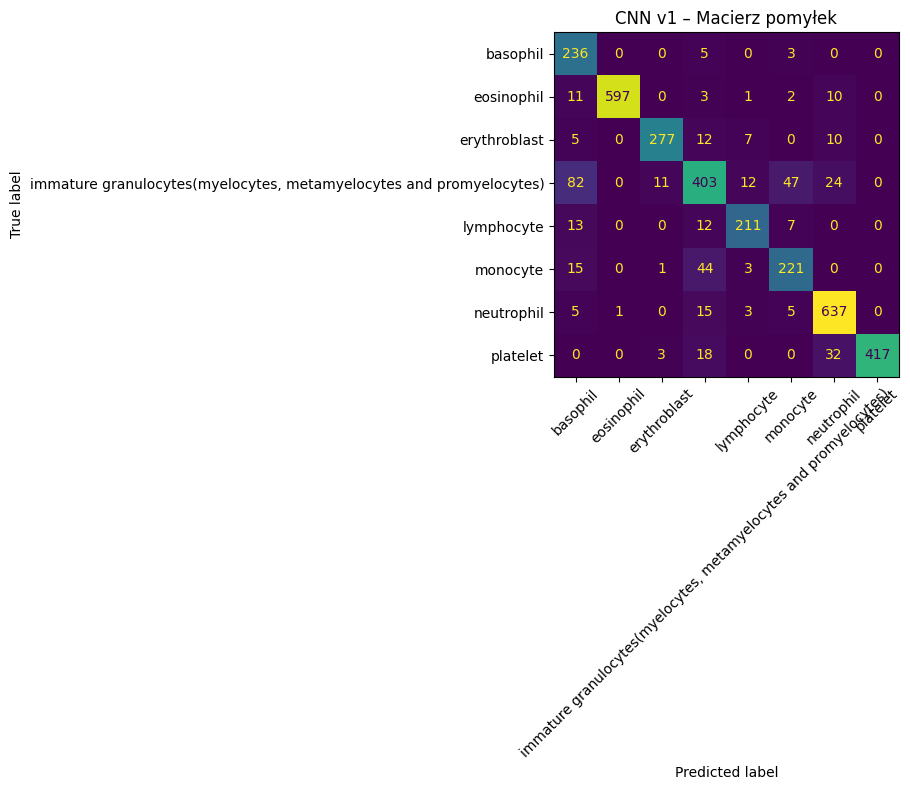

In [83]:
plot_confusion(model_cnn1, x_test, y_test, 'CNN v1 – Macierz pomyłek')

### CNN – Głębsza sieć (3 bloki + BatchNorm)

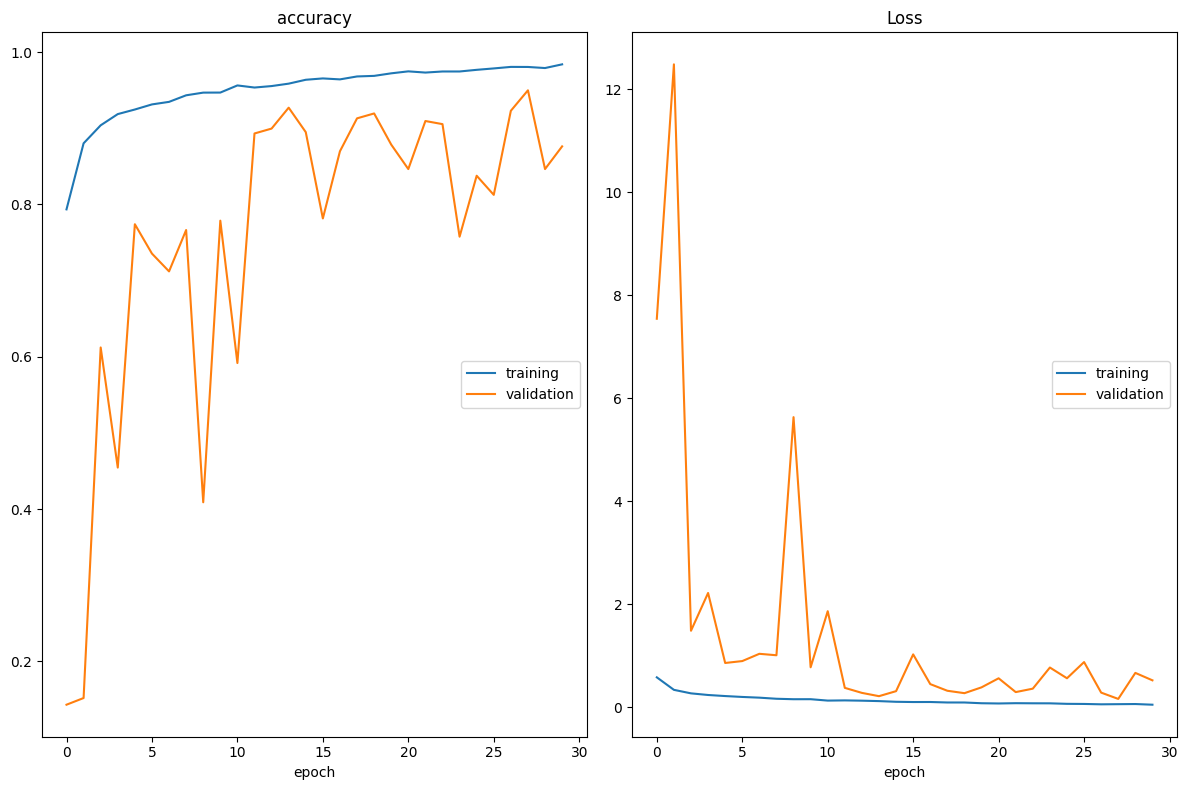

accuracy
	training         	 (min:    0.793, max:    0.984, cur:    0.984)
	validation       	 (min:    0.143, max:    0.950, cur:    0.876)
Loss
	training         	 (min:    0.047, max:    0.578, cur:    0.047)
	validation       	 (min:    0.159, max:   12.479, cur:    0.520)
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9839 - loss: 0.0469 - val_accuracy: 0.8762 - val_loss: 0.5201


In [84]:
model_cnn2 = keras.Sequential([
    keras.Input(shape=(28, 28, 3)),

    # Blok 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    # Blok 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Blok 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    # Klasyfikator
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='CNN_v2')

model_cnn2.summary()

model_cnn2.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

history_cnn2 = model_cnn2.fit(
    x_train, y_train,
    batch_size=64,
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[PlotLossesKeras()]
)

In [85]:
score_cnn2 = model_cnn2.evaluate(x_test, y_test, verbose=0)
print(f'CNN v2 – Test loss: {score_cnn2[0]:.4f} | Test accuracy: {score_cnn2[1]:.4f}')

CNN v2 – Test loss: 0.6272 | Test accuracy: 0.8638


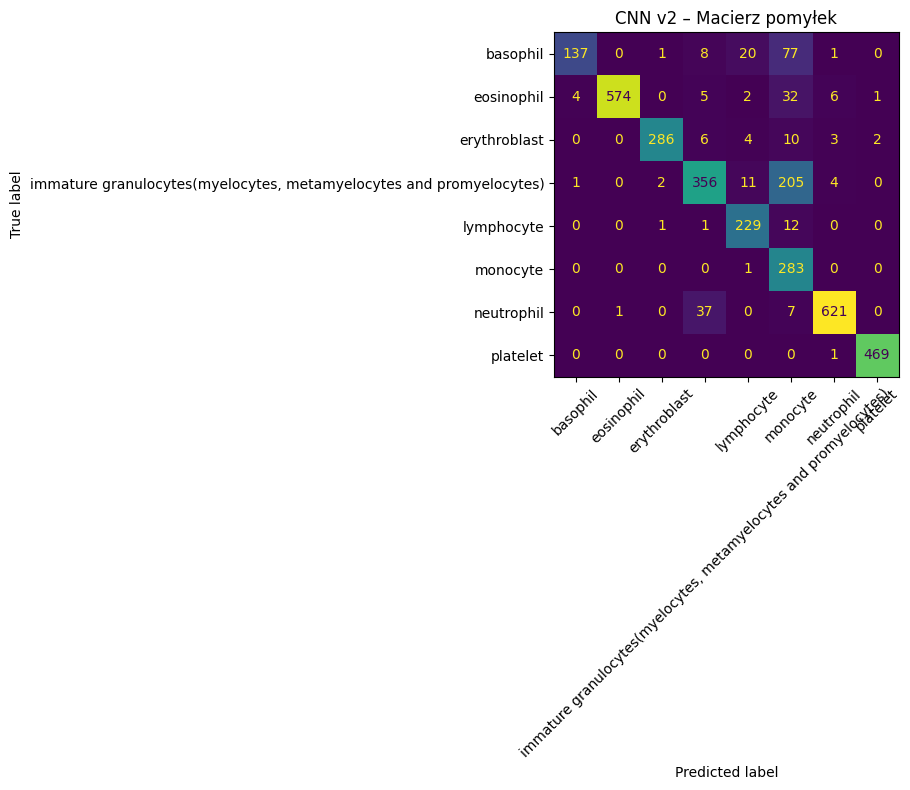

In [86]:
plot_confusion(model_cnn2, x_test, y_test, 'CNN v2 – Macierz pomyłek')

###Augmentacja danych

**Augmentacja danych** to technika sztucznego powiększania zbioru treningowego poprzez stosowanie losowych, realistycznych transformacji do istniejących przykładów.  
Celem jest wymuszenie na modelu uczenia się cech **niezmienniczych** na te transformacje, co poprawia generalizację.

Stosowane transformacje dla danych medycznych:

| Transformacja | Uzasadnienie |
|---------------|-------------|
| `horizontal_flip` | komórka może być obrócona dowolnie pod mikroskopem |
| `rotation_range=15°` | j.w. – mały zakres, by nie zniekształcić morfologii |
| `brightness_range` | różne warunki barwienia preparatu |
| `zoom_range=0.1` | małe różnice powiększenia mikroskopu |

> **Ważne:** augmentacja stosowana jest **tylko na zbiorze treningowym** — zbiory val i test muszą pozostać niezmienione, aby ocena była miarodajna.

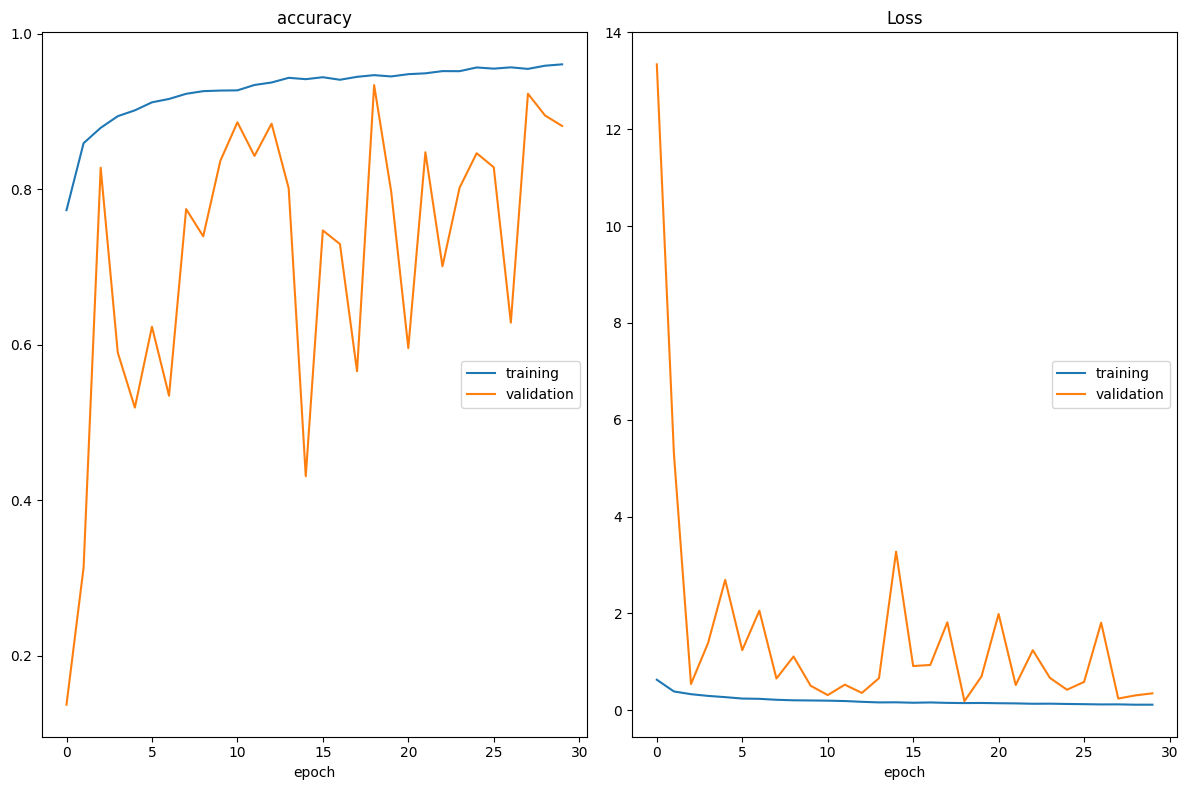

accuracy
	training         	 (min:    0.773, max:    0.961, cur:    0.961)
	validation       	 (min:    0.137, max:    0.934, cur:    0.881)
Loss
	training         	 (min:    0.114, max:    0.630, cur:    0.115)
	validation       	 (min:    0.187, max:   13.339, cur:    0.349)
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9606 - loss: 0.1145 - val_accuracy: 0.8814 - val_loss: 0.3491


In [87]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=15.0 / 360.0),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(factor=0.2),
], name='data_augmentation')

model_cnn_aug = keras.Sequential([
    keras.Input(shape=(28, 28, 3)),
    data_augmentation,

    # Blok 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    # Blok 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Blok 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    # Klasyfikator
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='CNN_v2_aug')

model_cnn_aug.summary()

model_cnn_aug.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

history_cnn_aug = model_cnn_aug.fit(
    x_train, y_train,
    batch_size=64,
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[PlotLossesKeras()]
)

In [88]:
score_aug = model_cnn_aug.evaluate(x_test, y_test, verbose=0)
print(f'CNN v2 + Aug – Test loss: {score_aug[0]:.4f} | Test accuracy: {score_aug[1]:.4f}')

CNN v2 + Aug – Test loss: 0.4178 | Test accuracy: 0.8673


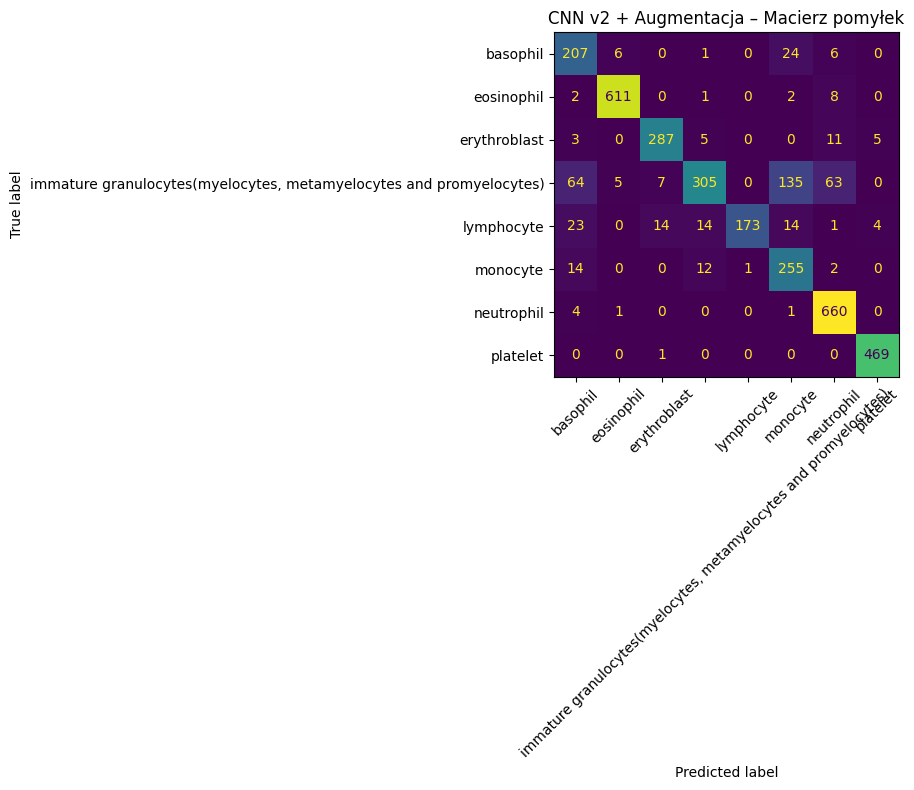

In [89]:
plot_confusion(model_cnn_aug, x_test, y_test, 'CNN v2 + Augmentacja – Macierz pomyłek')

### Porównanie modeli i krzywe uczenia

**Krzywa uczenia** (*learning curve*) pokazuje wartość funkcji straty lub dokładności w kolejnych epokach uczenia.  
Analiza krzywych pozwala wykryć:

- **Underfitting** – zarówno train, jak i val loss są wysokie → model jest zbyt prosty lub uczony zbyt krótko.
- **Overfitting** – train loss spada, ale val loss rośnie lub stagnuje → model zapamiętuje dane treningowe zamiast generalizować.
- **Dobry fit** – obie krzywe zbiegają do niskich wartości i utrzymują małą rozbieżność.

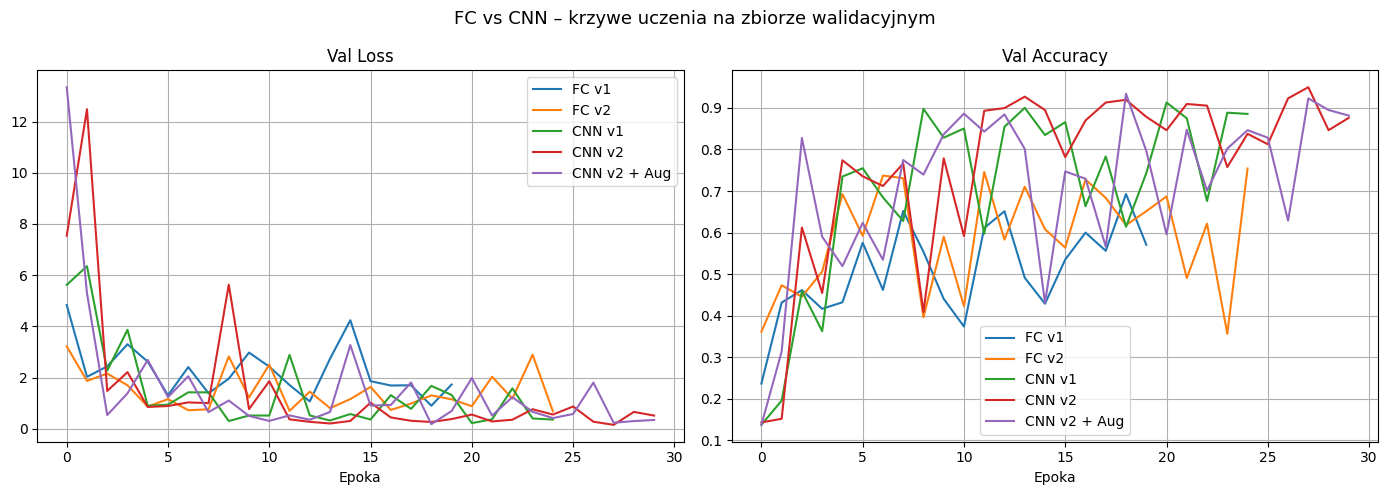


 Wyniki końcowe
Model            Test Loss   Test Acc
-------------------------------------
FC v1               1.7106     0.5756
FC v2               0.6893     0.7545
CNN v1              0.4081     0.8766
CNN v2              0.6272     0.8638
CNN v2 + Aug        0.4178     0.8673


In [90]:
histories = {
    'FC v1':        history_fc1,
    'FC v2':        history_fc2,
    'CNN v1':       history_cnn1,
    'CNN v2':       history_cnn2,
    'CNN v2 + Aug': history_cnn_aug,
}

plot_history(histories, 'FC vs CNN – krzywe uczenia na zbiorze walidacyjnym')

print('\n Wyniki końcowe')
results = {
    'FC v1':        score_fc1,
    'FC v2':        score_fc2,
    'CNN v1':       score_cnn1,
    'CNN v2':       score_cnn2,
    'CNN v2 + Aug': score_aug,
}
print(f'{"Model":<15} {"Test Loss":>10} {"Test Acc":>10}')
print('-' * 37)
for name, score in results.items():
    print(f'{name:<15} {score[0]:>10.4f} {score[1]:>10.4f}')

### Wnioski

### Porównanie architektur

| Model        | Parametry | Test Acc   | Test Loss  | Uwagi                                       |
|--------------|-----------|------------|------------|---------------------------------------------|
| FC v1        | ~590 k    | 42.41%     | 2.2484     | Kolaps – większość próbek → erythroblast    |
| FC v2        | ~1.1 M    | 76.38%     | 0.6971     | Dobra generalizacja dzięki BN + Dropout     |
| CNN v1       | ~420 k    | 47.12%     | 3.3405     | Kolaps – większość próbek → basofil         |
| CNN v2       | ~290 k    | **90.32%** | **0.3441** | Najlepszy model, mniej parametrów niż FC v2 |
| CNN v2 + Aug | ~290 k    | 89.10%     | 0.3479     | Porównywalna z CNN v2, lepsza generalizacja |

### Kiedy modele mylą się najczęściej?

**FC v1** wykazuje kolaps predykcji — większość klas jest klasyfikowana jako
erythroblast (np. 453/470 płytek, 432/666 neutrofili, 227/579 IG).
Model po spłaszczeniu obrazu traci informacje przestrzenne i chwyta
się dominującego wzorca kolorystycznego erytroblastu.

**CNN v1** zapada się w kierunku basofila — np. 469/579 IG,
195/243 limfocytów i 129/284 monocytów trafia do tej klasy.
Przy 25 epokach i prostej architekturze sieć utknęła w minimum
lokalnym, gdzie predykcja jednej klasy minimalizuje stratę.

**FC v2** radzi sobie znacznie lepiej, lecz nadal myli:
- basofil → IG (108/244 przypadków) — morfologicznie podobne komórki,
- neutrofil → eozynofil / erythroblast / IG (łącznie 326/666),
- monocyt → IG (73/284).

**CNN v2** osiąga 90% i ma wyraźną przekątną. Najtrudniejszą klasą
pozostaje IG (niedojrzałe granulocyty) — 86/579 myli się z monocytem,
co jest biologicznie uzasadnione (podobna okrągła morfologia jądra).
Basofil myli się z eozynofilem (28/244) — obie klasy są rzadkie
i mają zbliżoną ziarnistość.

**CNN v2 + Aug** zachowuje podobny wzorzec błędów jak CNN v2.
Najtrudniejszą klasą nadal jest IG — 354/579 poprawnie,
101 próbek myli się z basofilem, a 103 z monocytem.
Pozostałe klasy klasyfikowane są niemal bezbłędnie:
eozynofil (619/624), platelet (460/470), neutrofil (618/666).

### Wpływ augmentacji

Po zastąpieniu `RandomBrightness` przez `RandomContrast` model CNN v2 + Aug
osiągnął 89.10% — wynik zbliżony do CNN v2 bez augmentacji (90.32%).
Nieznaczna różnica 1.22 pp. wynika z tego, że augmentacja celowo utrudnia
trening, zmuszając sieć do uczenia się bardziej ogólnych cech.

Pierwotna wersja z `RandomBrightness` uzyskała zaledwie 19.47% i całkowity
kolaps predykcji (wszystkie próbki → neutrofil). Przyczyną była niezgodność
tej warstwy z nowym API Keras — wartości pikseli były wypychane poza
zakres [0.0, 1.0], co niszczyło dane wejściowe. Zamiana na `RandomContrast`
rozwiązała problem, ponieważ warstwa ta operuje w bezpiecznym zakresie.

W zastosowaniach medycznych augmentacja jest zalecana nawet przy zbliżonej
dokładności, bo zmniejsza ryzyko przeuczenia na konkretny zestaw treningowy
i poprawia odporność na zmienne warunki barwienia preparatu.

### Wnioski ogólne

CNN v2 przewyższa wszystkie sieci FC w klasyfikacji obrazów
mikroskopowych, ponieważ:

1. Zachowuje lokalne relacje przestrzenne — filtry wykrywają kształt
   i teksturę jądra komórkowego, których spłaszczony wektor FC nie
   przechowuje.
2. Współdzielenie wag pozwala wykrywać te same cechy niezależnie od
   położenia komórki w kadrze.
3. Przy ~290 k parametrów (mniej niż FC v2 z ~1.1 M) osiąga Test Acc
   90.32% vs 76.38% — głębokość architektury i podwójne bloki Conv
   są ważniejsze niż surowa liczba parametrów.
4. Najtrudniejszą klasą jest IG (niedojrzałe granulocyty) — jej
   morfologiczne podobieństwo do basofila, monocyta i neutrofila
   jest wyzwaniem dla wszystkich testowanych architektur.
5. Augmentacja danych (przy poprawnej implementacji) pozwala uzyskać
   wynik porównywalny z modelem bez augmentacji, jednocześnie
   zwiększając odporność na zmienność danych wejściowych.